In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [ ]:
import pandas as pd
df=pd.read_csv(r'WA_Fn-UseC_-HR-Employee-Attrition.csv')
print('Shape:',df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


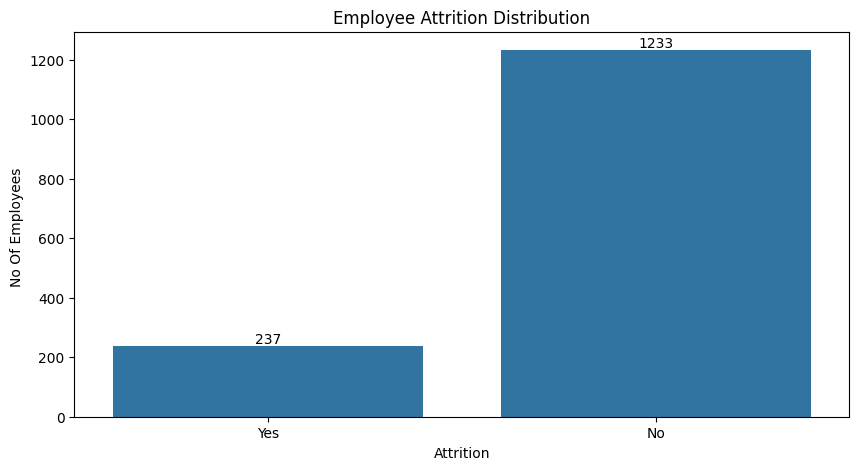

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
ax=sns.countplot(x='Attrition',data=df)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("No Of Employees ")
for container in ax.containers:
    ax.bar_label(container)
plt.show()


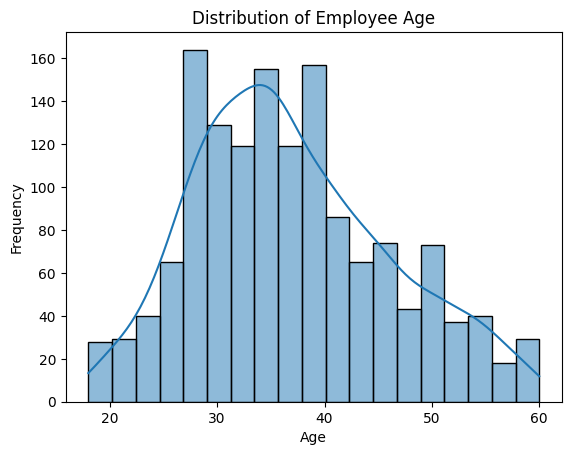

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Employee Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

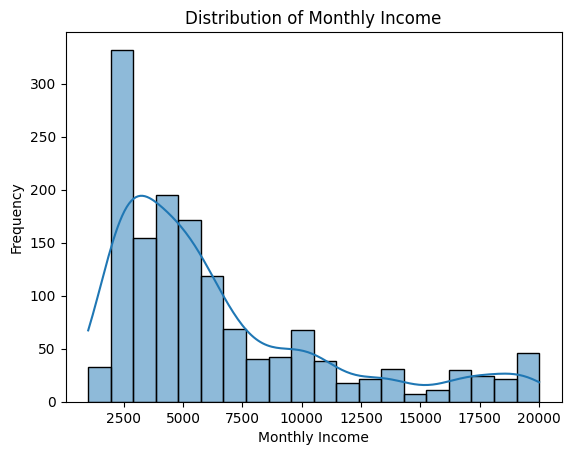

In [ ]:
sns.histplot(df['MonthlyIncome'],kde=True)
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

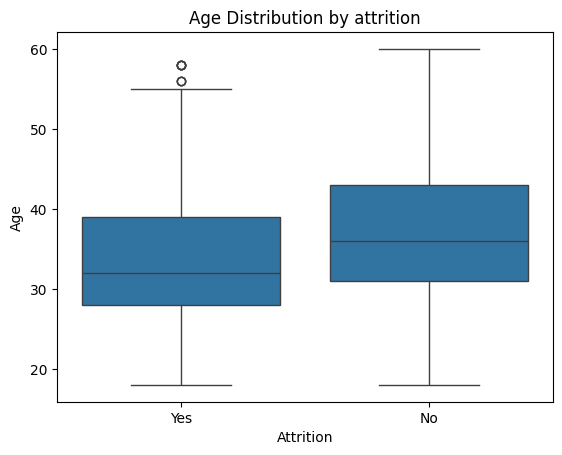

In [ ]:
sns.boxplot(x='Attrition',y='Age',data=df)
plt.title("Age Distribution by attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

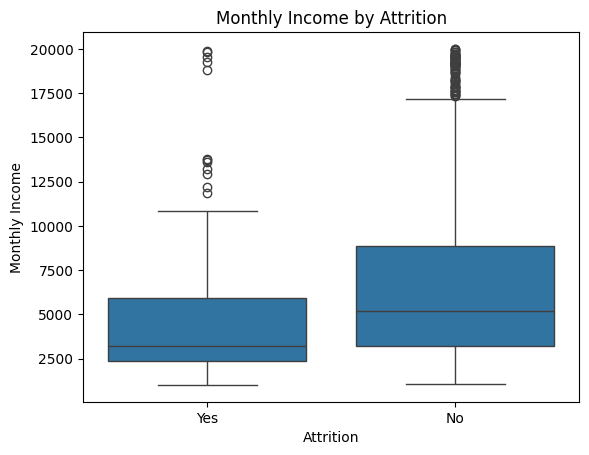

In [ ]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

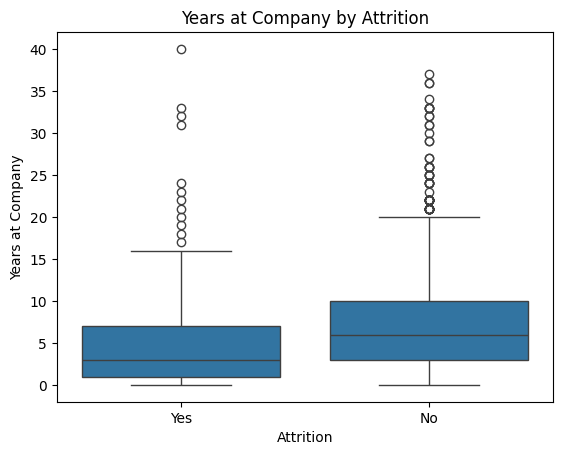

In [ ]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')
plt.show()

Text(0, 0.5, 'Number of Employees')

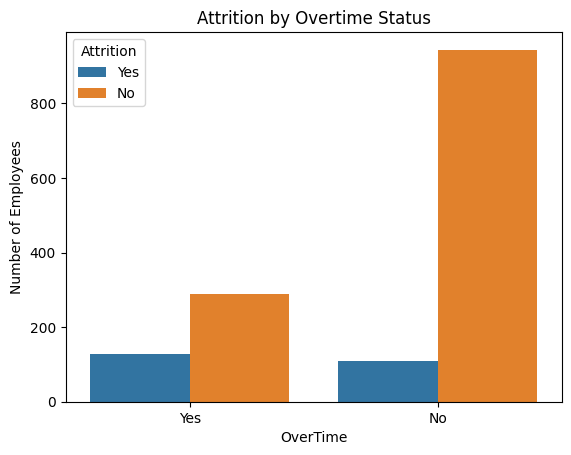

In [ ]:
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)
plt.title('Attrition by Overtime Status')
plt.xlabel('OverTime')
plt.ylabel('Number of Employees')

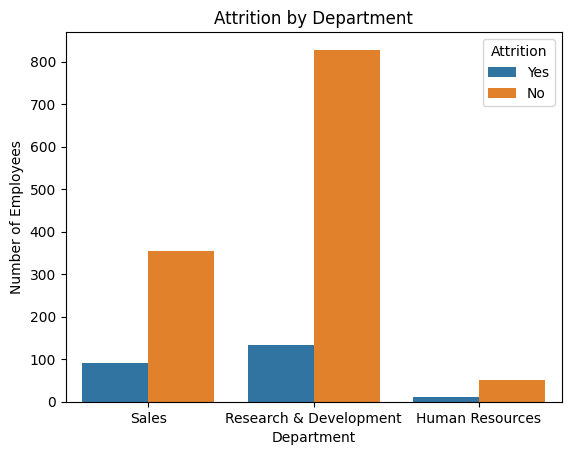

In [ ]:
sns.countplot(x='Department',hue="Attrition",data=df)
plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

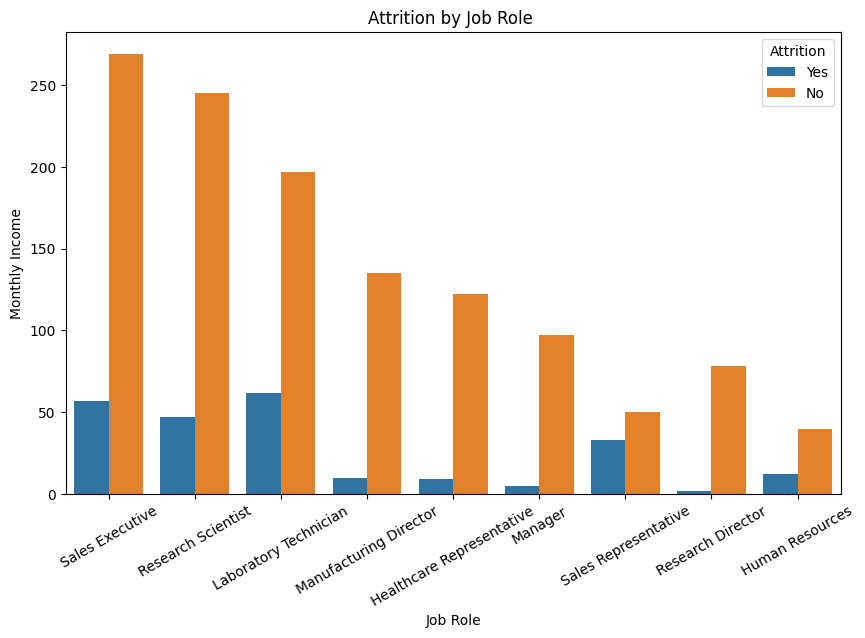

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="JobRole",hue='Attrition',data=df)
plt.title("Attrition by Job Role ")
plt.xlabel("Job Role")
plt.ylabel("Monthly Income")
plt.xticks(rotation=30)
plt.show()

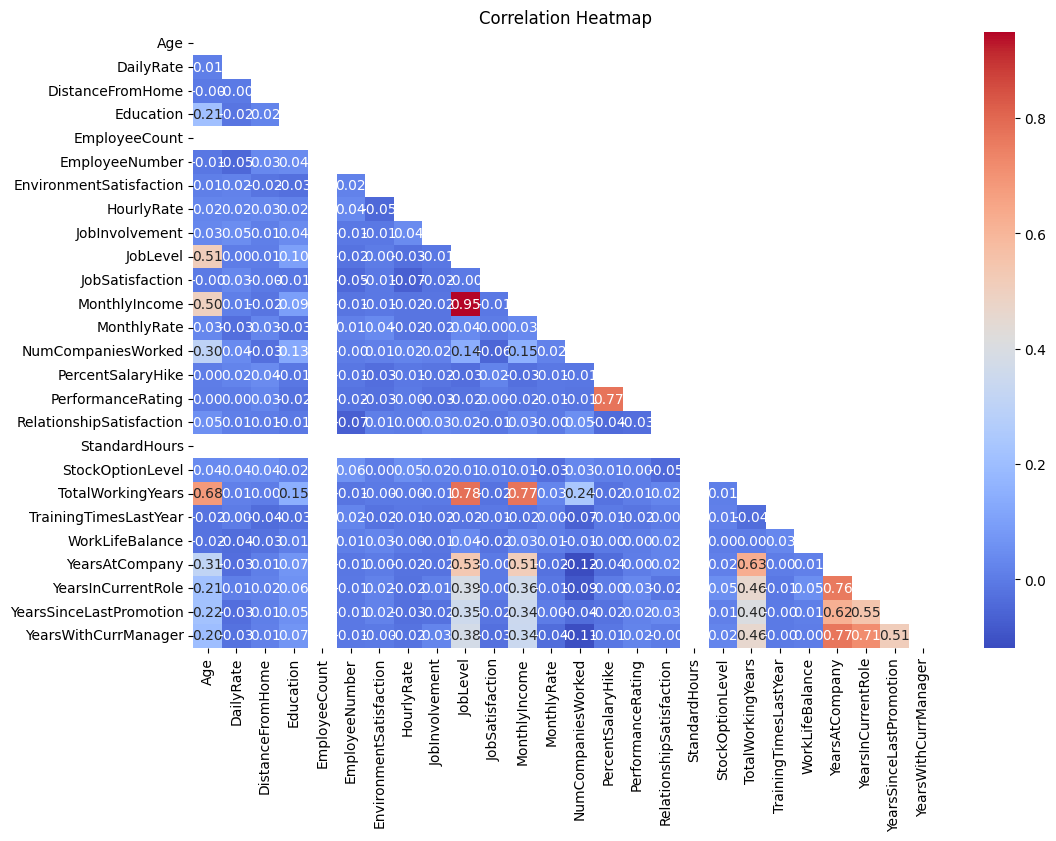

In [ ]:
import numpy as np

corr = df.select_dtypes(include=['int64']).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df1 = df.copy()

df1['Attrition'] = df1['Attrition'].map({
    'Yes':1,
    'No':0
})

corr = df1.select_dtypes(include=['int64']).corr()

corr['Attrition'].sort_values(ascending=False)

,Attrition
Attrition,1.000000
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
EmployeeNumber,-0.010577
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019


In [ ]:
import sqlite3

conn = sqlite3.connect('hr.db')

df.to_sql(
    'hr_attrition',
    conn,
    if_exists='replace',
    index=False
)

1470

In [ ]:
query="""select count(*) as Total_Employees
from hr_attrition """
pd.read_sql(query,conn)

,Total_Employees
0,1470


In [ ]:
query="""select attrition ,count(*) as Employee_count
from hr_attrition
group by attrition"""
pd.read_sql(query,conn)

,Attrition,Employee_count
0,No,1233
1,Yes,237


In [ ]:
query = """
SELECT
    Department,
    ROUND(AVG(MonthlyIncome),2) AS Avg_Salary
FROM hr_attrition
GROUP BY Department
ORDER BY Avg_Salary DESC
"""

pd.read_sql(query, conn)

,Department,Avg_Salary
0,Sales,6959.17
1,Human Resources,6654.51
2,Research & Development,6281.25


In [ ]:
query = """
SELECT
    Department,
    COUNT(*) AS Employees_Left
FROM hr_attrition
WHERE Attrition='Yes'
GROUP BY Department
ORDER BY Employees_Left DESC
"""

pd.read_sql(query, conn)

,Department,Employees_Left
0,Research & Development,133
1,Sales,92
2,Human Resources,12


In [ ]:
query = """
SELECT
    Attrition,
    ROUND(AVG(MonthlyIncome),2) AS Avg_Income
FROM hr_attrition
GROUP BY Attrition
"""

pd.read_sql(query, conn)

,Attrition,Avg_Income
0,No,6832.74
1,Yes,4787.09


In [ ]:
query = """
SELECT
    OverTime,
    Attrition,
    COUNT(*) AS Employee_Count
FROM hr_attrition
GROUP BY OverTime, Attrition
ORDER BY OverTime
"""

pd.read_sql(query, conn)

,OverTime,Attrition,Employee_Count
0,No,No,944
1,No,Yes,110
2,Yes,No,289
3,Yes,Yes,127


In [ ]:
query = """
SELECT
    Attrition,
    ROUND(AVG(Age),2) AS Avg_Age
FROM hr_attrition
GROUP BY Attrition
"""

pd.read_sql(query, conn)

,Attrition,Avg_Age
0,No,37.56
1,Yes,33.61


In [ ]:
query = """
SELECT
    EmployeeNumber,
    MonthlyIncome
FROM hr_attrition
ORDER BY MonthlyIncome DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,EmployeeNumber,MonthlyIncome
0,259,19999
1,1035,19973
2,1191,19943
3,226,19926
4,787,19859
5,1282,19847
6,1038,19845
7,1740,19833
8,1255,19740
9,1338,19717


In [ ]:
query = """
SELECT
    EmployeeNumber,
    MonthlyIncome
FROM hr_attrition
WHERE MonthlyIncome >
(
    SELECT AVG(MonthlyIncome)
    FROM hr_attrition
)
"""

pd.read_sql(query, conn)

,EmployeeNumber,MonthlyIncome
0,12,9526
1,20,9980
2,23,15427
3,28,11994
4,32,19094
...,...,...
488,2045,6652
489,2055,10854
490,2056,12031
491,2057,9936


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
df = df.drop(
    columns=[
        'EmployeeCount',
        'EmployeeNumber',
        'StandardHours',
        'Over18'
    ],errors="ignore"
)

df.shape

(1470, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [ ]:
df.select_dtypes(include='object').columns.tolist()

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [ ]:
df['Attrition']=df['Attrition'].map({'Yes':1,'No':0})
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
X.shape, y.shape

((1470, 30), (1470,))

In [ ]:
categorical_cols=X.select_dtypes(include="object").columns.tolist()
categorical_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [ ]:
X_encoded = pd.get_dummies(X,columns=categorical_cols, drop_first=True,dtype=int)

In [ ]:
X_encoded.shape

(1470, 44)

In [ ]:
df.shape

(1470, 31)

In [ ]:
%whos

Variable           Type            Data/Info
--------------------------------------------
X                  DataFrame             Age     BusinessTra<...>n[1470 rows x 30 columns]
X_encoded          DataFrame             Age  DailyRate  Dis<...>n[1470 rows x 44 columns]
ax                 Axes            Axes(0.125,0.11;0.775x0.77)
categorical_cols   list            n=7
conn               Connection      <sqlite3.Connection object at 0x7afe29396890>
container          BarContainer    <BarContainer object of 2 artists>
corr               DataFrame                                <...>n\n[27 rows x 27 columns]
df                 DataFrame             Age  Attrition     <...>n[1470 rows x 31 columns]
df1                DataFrame             Age  Attrition     <...>n[1470 rows x 35 columns]
files              module          <module 'google.colab.fil<...>s/google/colab/files.py'>
mask               ndarray         26x26: 676 elems, type `bool`, 676 bytes
np                 module          

In [ ]:
df['Attrition'] = y

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
df['Attrition'].isna().sum()

np.int64(0)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1176, 44), (294, 44), (1176,), (294,))

In [ ]:
stratify=y

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

X_vif = X_train.copy()

X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data[vif_data["Feature"] != "const"]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data.head(15)

,Feature,VIF
26,Department_Research & Development,52.917041
27,Department_Sales,52.496942
28,EducationField_Life Sciences,24.740868
30,EducationField_Medical,22.172740
10,MonthlyIncome,17.158129
40,JobRole_Sales Executive,14.591916
8,JobLevel,13.532470
29,EducationField_Marketing,11.655213
32,EducationField_Technical Degree,9.700523
34,JobRole_Human Resources,8.310459


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

corr_matrix = df[numeric_cols].corr()

corr_matrix["Attrition"].sort_values(ascending=False)


,Attrition
Attrition,1.000000
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019
RelationshipSatisfaction,-0.045872


In [ ]:
numeric_features = X.select_dtypes(include=np.number)

feature_corr = numeric_features.corr()

feature_corr

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,...,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,...,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


In [ ]:
corr_pairs = (
    feature_corr
    .where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(15)

JobLevel                 MonthlyIncome              0.950300
                         TotalWorkingYears          0.782208
PercentSalaryHike        PerformanceRating          0.773550
MonthlyIncome            TotalWorkingYears          0.772893
YearsAtCompany           YearsWithCurrManager       0.769212
                         YearsInCurrentRole         0.758754
YearsInCurrentRole       YearsWithCurrManager       0.714365
Age                      TotalWorkingYears          0.680381
TotalWorkingYears        YearsAtCompany             0.628133
YearsAtCompany           YearsSinceLastPromotion    0.618409
YearsInCurrentRole       YearsSinceLastPromotion    0.548056
JobLevel                 YearsAtCompany             0.534739
MonthlyIncome            YearsAtCompany             0.514285
YearsSinceLastPromotion  YearsWithCurrManager       0.510224
Age                      JobLevel                   0.509604
dtype: float64

In [ ]:
corr_pairs.tail(15)

,,0
TotalWorkingYears,TrainingTimesLastYear,-0.035662
PercentSalaryHike,YearsAtCompany,-0.035991
MonthlyRate,YearsWithCurrManager,-0.036746
NumCompaniesWorked,YearsSinceLastPromotion,-0.036814
DistanceFromHome,TrainingTimesLastYear,-0.036942
DailyRate,WorkLifeBalance,-0.037848
PercentSalaryHike,RelationshipSatisfaction,-0.040490
RelationshipSatisfaction,StockOptionLevel,-0.045952
EnvironmentSatisfaction,HourlyRate,-0.049857
JobSatisfaction,NumCompaniesWorked,-0.055699


In [ ]:
X_reg = X_encoded.drop('MonthlyIncome', axis=1)
y_reg = df['MonthlyIncome']

In [ ]:
X_reg.shape, y_reg.shape

((1470, 43), (1470,))

In [ ]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_reg_train.shape, X_reg_test.shape

((1176, 43), (294, 43))

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_reg_train, y_reg_train)

LinearRegression()

In [ ]:
y_pred = lr_model.predict(X_reg_test)

In [ ]:
y_pred[:5]

array([5927.14354368, 5479.19087695, 2677.657144  , 9112.86872905,
       5810.5795728 ])

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_reg_test, y_pred)

print("R²:", r2)

R²: 0.9376408712460691


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_reg_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 891.7392662906608
RMSE: 1167.426333050122


In [ ]:
n = X_reg_test.shape[0]
p = X_reg_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.926915101100393


In [ ]:
residuals = y_reg_test - y_pred

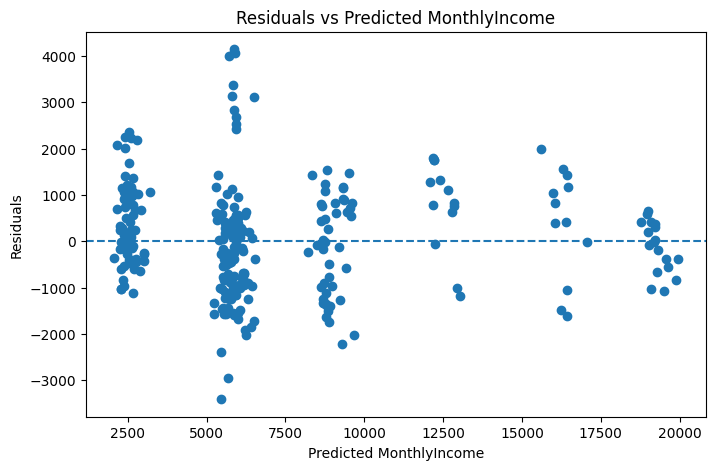

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted MonthlyIncome")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted MonthlyIncome")

plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

X_bp = sm.add_constant(X_reg_test)

bp_test = het_breuschpagan(residuals, X_bp)

labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']

for label, value in zip(labels, bp_test):
    print(label, ":", value)

LM Statistic : 53.034243001338844
LM p-value : 0.1404279156005238
F Statistic : 1.279595183736087
F p-value : 0.12731675090987635


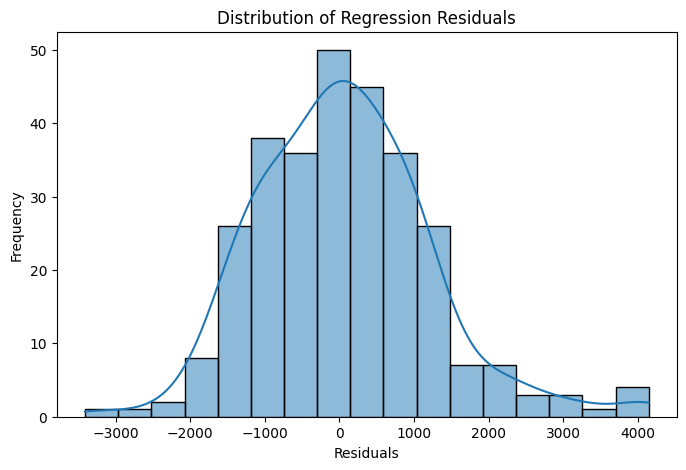

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Residuals")

plt.show()


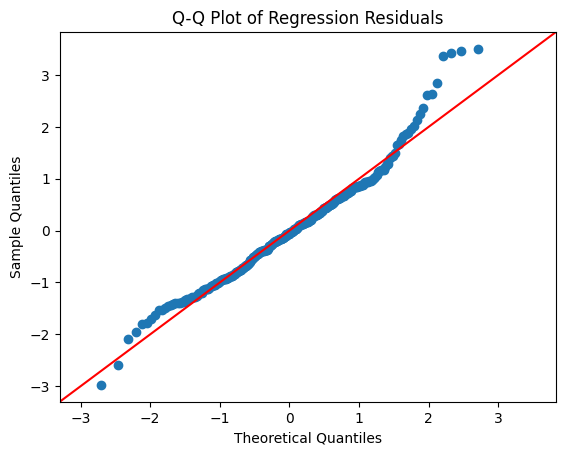

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(residuals, line='45', fit=True)

plt.title("Q-Q Plot of Regression Residuals")
plt.show()


In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

X_train_sm = sm.add_constant(X_reg_train)

model_sm = sm.OLS(y_reg_train, X_train_sm).fit()

influence = model_sm.get_influence()

cooks_distance = influence.cooks_distance[0]

print(cooks_distance[:10])

[2.94366432e-06 6.51648725e-04 4.70267454e-04 2.14205039e-04
 6.60407347e-04 6.99469686e-03 5.23076362e-04 1.96832327e-04
 4.84822885e-06 8.66339595e-03]


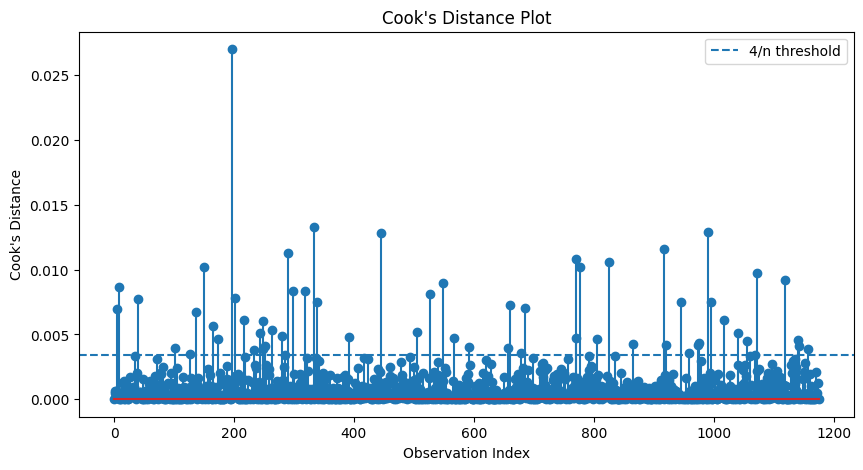

In [ ]:
plt.figure(figsize=(10, 5))

plt.stem(cooks_distance)

plt.axhline(
    4 / len(X_reg_train),
    linestyle='--',
    label='4/n threshold'
)

plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot")
plt.legend()

plt.show()

In [ ]:
threshold = 4 / len(X_reg_train)

influential_indices = np.where(cooks_distance > threshold)[0]

print("Threshold:", threshold)
print("Number of influential observations:", len(influential_indices))
print("Indices:", influential_indices)

Threshold: 0.003401360544217687
Number of influential observations: 58
Indices: [   5    9   40  101  126  136  150  165  174  196  202  216  234  243
  248  249  251  264  281  285  290  298  319  334  339  392  445  505
  527  548  567  592  657  661  679  685  770  771  777  806  826  866
  917  920  946  959  974  976  990  995 1017 1041 1055 1072 1119 1141
 1142 1157]


In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)

print("Durbin-Watson:", dw)

Durbin-Watson: 2.140704095467877


In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
0,83.877551
1,16.122449


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64

Testing distribution:
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
X_train.dtypes

,0
Age,int64
DailyRate,int64
DistanceFromHome,int64
Education,int64
EnvironmentSatisfaction,int64
HourlyRate,int64
JobInvolvement,int64
JobLevel,int64
JobSatisfaction,int64
MonthlyIncome,int64


In [ ]:
numerical_cols = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'Education',
    'EnvironmentSatisfaction',
    'HourlyRate',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'WorkLifeBalance',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [ ]:
scaler.fit_transform(X_train)

array([[ 1.09019402,  1.04945488, -0.89991452, ..., -0.92144268,
        -0.68154831, -0.63772923],
       [-1.6348276 , -0.52344929, -0.89991452, ...,  1.08525471,
        -0.68154831, -0.63772923],
       [ 0.98119316, -0.99208001, -0.77761018, ...,  1.08525471,
        -0.68154831, -0.63772923],
       ...,
       [-1.6348276 , -1.46320345, -0.16608847, ...,  1.08525471,
        -0.68154831, -0.63772923],
       [-0.10881549, -0.93225481, -0.89991452, ...,  1.08525471,
        -0.68154831,  1.56806362],
       [ 0.21818711, -0.09470203,  1.30156365, ..., -0.92144268,
        -0.68154831, -0.63772923]])

In [ ]:
scaler.transform(X_test)

array([[-1.41682587e+00,  6.48318281e-02,  4.45433249e-01, ...,
         1.08525471e+00, -6.81548307e-01, -6.37729225e-01],
       [ 7.63191429e-01,  7.80241491e-01, -8.99914522e-01, ...,
         1.08525471e+00, -6.81548307e-01, -6.37729225e-01],
       [-6.53819813e-01, -2.89133929e-01, -2.88392808e-01, ...,
        -9.21442675e-01, -6.81548307e-01, -6.37729225e-01],
       ...,
       [-1.08815489e-01,  1.62527242e+00,  4.45433249e-01, ...,
        -9.21442675e-01, -6.81548307e-01,  1.56806362e+00],
       [ 2.07120181e+00,  1.12423638e+00, -1.02221887e+00, ...,
         1.08525471e+00, -6.81548307e-01, -6.37729225e-01],
       [ 1.85375620e-04,  1.41588422e+00, -1.02221887e+00, ...,
        -9.21442675e-01,  1.46724743e+00, -6.37729225e-01]])

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = logistic_model.predict(X_test_scaled)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:10])

[0.0974376  0.00289232 0.182142   0.0045899  0.29854287 0.25321261
 0.00800043 0.01506742 0.00374778 0.11561723]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[238   9]
 [ 31  16]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8639455782312925
Precision: 0.64
Recall: 0.3404255319148936
F1 Score: 0.4444444444444444


In [ ]:
class_weight='balanced'

In [ ]:
logistic_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logistic_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred_balanced = logistic_balanced.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1 Score:", f1_score(y_test, y_pred_balanced))

Accuracy: 0.7551020408163265
Precision: 0.3563218390804598
Recall: 0.6595744680851063
F1 Score: 0.4626865671641791


In [ ]:
from sklearn.metrics import roc_auc_score

y_prob_baseline = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_balanced = logistic_balanced.predict_proba(X_test_scaled)[:, 1]

auc_baseline = roc_auc_score(y_test, y_prob_baseline)
auc_balanced = roc_auc_score(y_test, y_prob_balanced)

print("Baseline ROC-AUC:", auc_baseline)
print("Balanced ROC-AUC:", auc_balanced)

Baseline ROC-AUC: 0.8102334395727453
Balanced ROC-AUC: 0.8035145146007409


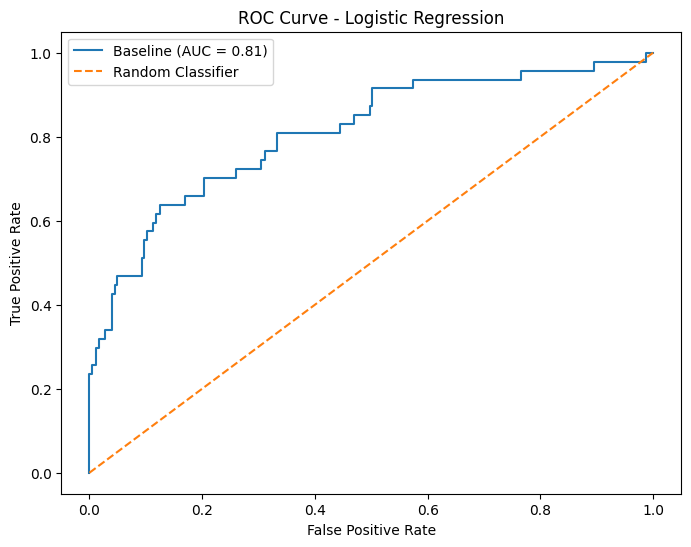

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ROC curve for baseline model
fpr_baseline, tpr_baseline, thresholds = roc_curve(
    y_test, y_prob_baseline
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f'Baseline (AUC = {auc_baseline:.2f})'
)

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [ ]:
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': logistic_balanced.coef_[0]
})

coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    'Abs_Coefficient',
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient,Abs_Coefficient
43,OverTime_Yes,1.623568,1.623568
23,BusinessTravel_Travel_Frequently,1.598904,1.598904
34,JobRole_Laboratory Technician,1.569722,1.569722
40,JobRole_Sales Representative,1.276684,1.276684
37,JobRole_Research Director,-1.117217,1.117217
30,EducationField_Other,-1.027636,1.027636
24,BusinessTravel_Travel_Rarely,0.906933,0.906933
42,MaritalStatus_Single,0.864752,0.864752
33,JobRole_Human Resources,0.645775,0.645775
16,TotalWorkingYears,-0.615535,0.615535


In [ ]:
import numpy as np

np.exp(1.623568)

np.float64(5.071151945598251)

In [ ]:
np.exp(-0.615535)

np.float64(0.5403517297889999)

In [ ]:
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])

coefficients.head(15)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
43,OverTime_Yes,1.623568,1.623568,5.071150
23,BusinessTravel_Travel_Frequently,1.598904,1.598904,4.947606
34,JobRole_Laboratory Technician,1.569722,1.569722,4.805314
40,JobRole_Sales Representative,1.276684,1.276684,3.584733
37,JobRole_Research Director,-1.117217,1.117217,0.327189
30,EducationField_Other,-1.027636,1.027636,0.357852
24,BusinessTravel_Travel_Rarely,0.906933,0.906933,2.476714
42,MaritalStatus_Single,0.864752,0.864752,2.374416
33,JobRole_Human Resources,0.645775,0.645775,1.907464
16,TotalWorkingYears,-0.615535,0.615535,0.540352


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob_balanced >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.284 | Recall: 0.809 | F1: 0.420
Threshold: 0.4 | Precision: 0.349 | Recall: 0.809 | F1: 0.487
Threshold: 0.5 | Precision: 0.356 | Recall: 0.660 | F1: 0.463
Threshold: 0.6 | Precision: 0.458 | Recall: 0.574 | F1: 0.509
Threshold: 0.7 | Precision: 0.525 | Recall: 0.447 | F1: 0.483


In [ ]:
y_pred_final = (y_prob_balanced >= 0.6).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(y_test, y_pred_final)

print(cm_final)

[[215  32]
 [ 20  27]]


In [ ]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       247
           1       0.46      0.57      0.51        47

    accuracy                           0.82       294
   macro avg       0.69      0.72      0.70       294
weighted avg       0.84      0.82      0.83       294

